In [103]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [174]:
# Load data
results_df = pd.read_table('./data_here/all_results.txt', delimiter='\t')

def read_interest_area(trial_name): #edit for L and R cases
    boundary = []
    subject = ['',[],[]]
    with open("./data_here/interest areas/"+trial_name, "r") as file:
        
        content = file.read()
        bounds = content.split('\n')
        for i in range(2):
            items = bounds[i].split()
            subject[0] = items[-1]
            
            x_coords = []
            y_coords = []
            for coord in items[2:-1]:
                x, y = map(int, coord.split(','))
                x_coords.append(x)
                y_coords.append(y)
                
            subject[1] = x_coords
            subject[2] = y_coords
            boundary.append(subject)
            subject = ['',[],[]]

    return boundary

In [191]:
def get_file_names():

    folder_path = Path("./data_here/interest areas")
    file_names = [file.name for file in folder_path.iterdir() if file.is_file()]

    return file_names

In [192]:
def plot_trial(x_plots, y_plots, trial_name):
    # Filter out None values
    valid_indices = ~np.isnan(x_plots) & ~np.isnan(y_plots)
    x_plots = np.array(x_plots)[valid_indices]
    y_plots = np.array(y_plots)[valid_indices]

    boundary = read_interest_area(trial_name)
    x_bound1 = boundary[0][1]
    x_bound1.append(x_bound1[0])
    y_bound1 = boundary[0][2]
    y_bound1.append(y_bound1[0])
    x_bound2 = boundary[1][1]
    x_bound2.append(x_bound2[0])
    y_bound2 = boundary[1][2]
    y_bound2.append(y_bound2[0])
    
    plt.figure(figsize=(8, 6))
    plt.plot(x_plots, y_plots, marker='o', linestyle='-', color='blue')
    plt.plot(x_bound1, y_bound1, marker='o', linestyle='-', color='red')
    plt.plot(x_bound2, y_bound2, marker='o', linestyle='-', color='green')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title('Trial')
    plt.show()

def get_trial_coords(subitem):
    filtered_df = results_df[results_df['subitem'] == subitem]
    x_plots = filtered_df['X_coord'].replace('empty', None).astype(float).tolist()
    y_plots = filtered_df['Y_coord'].replace('empty', None).astype(float).tolist()
    return x_plots, y_plots

def get_trial_name(item):
    picture_name = results_df[results_df['item'] == int(item)]
    pic_name_split = picture_name['picture_name'].unique()[0][:-7].split("_")
    subject1 = pic_name_split[0]
    subject2 = pic_name_split[-1]

    file_names = get_file_names()
    for file in file_names:
        split_file = file.split("_")
        if subject1 in split_file and subject2 in split_file: # This doesn't work, items 3 7 10 17 etc does not have the same subject names
            return file

    return None

def show_trial_plot(subitem):
    x_coord, y_coord = get_trial_coords(subitem)
    plot_trial(x_coord, y_coord, get_trial_name(subitem[7:]))  

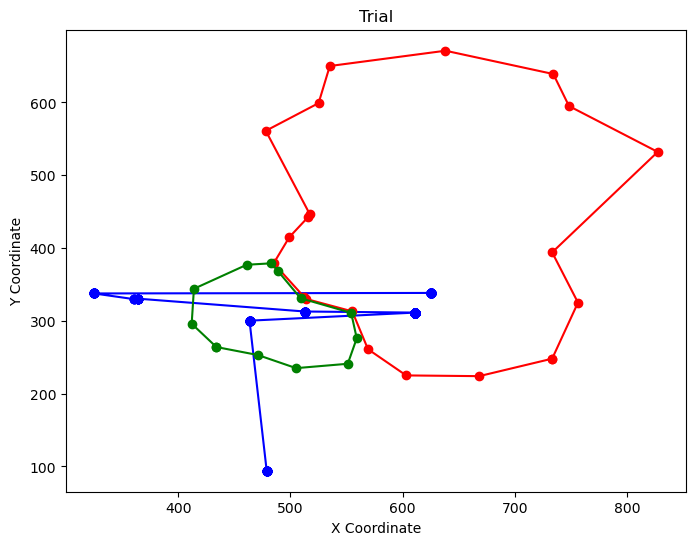

In [193]:
show_trial_plot('sub201_6')
#get_trial_name('25')

In [63]:
print(results_df['picture_name'].unique())
print(results_df.columns)

['stork_carrying_baby_active' 'thief_stealing_painting_active'
 'hippie_finding_drugs_active' 'man_lifting_bench_active'
 'paparazzi_following_queen_active' 'girl_grabbing_cake_active'
 'policeman_stopping_truck_active' 'pelican_approaching_balloon_active'
 'shark_attacking_man_active' 'farmer_pulling_donkey_active'
 'jeweler_examining_diamonds_active' 'punk_kicking_fence_active'
 'frog_capturing_fly_active' 'army_beseiging_castle_active'
 'manager_congratulating_intern_active' 'cat_scratching_couch_active'
 'ambulance_knocking_over_woman_active' 'worker_moving_armchair_active'
 'lightning_striking_church_active' 'dog_running_after_postman_active'
 'artist_carving_statue_active' 'sheriff_lassoing_cowboy_active'
 'man_brushing_suit_active' 'baby_biting_bear_active'
 'burglar_smashing_window_active' 'elephant_picking_up_clown_active'
 'bodyguard_approaching_president_active' 'woman_chasing_chicken_active'
 'bomb_landing_on_ship_active' 'lifeguard_finding_child_active'
 'eskimo_attacking_